# Credit Card Fraud Detection Using The Machine Learning

# Importing Library

In [2]:
#importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#import all the required library for machine learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report,confusion_matrix


from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings("ignore")

# Data Collection

In [3]:
#load the dataset
creditcard_data = pd.read_csv("creditcard.csv")

In [4]:
# print the 5 rows
creditcard_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


# Explorty Data Analysis

In [5]:
# check the dataset shape
creditcard_data.shape

(14636, 31)

In [6]:
#check the dataset datatype
creditcard_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14636 entries, 0 to 14635
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    14636 non-null  int64  
 1   V1      14636 non-null  float64
 2   V2      14636 non-null  float64
 3   V3      14636 non-null  float64
 4   V4      14636 non-null  float64
 5   V5      14636 non-null  float64
 6   V6      14636 non-null  float64
 7   V7      14636 non-null  float64
 8   V8      14636 non-null  float64
 9   V9      14636 non-null  float64
 10  V10     14636 non-null  float64
 11  V11     14636 non-null  float64
 12  V12     14636 non-null  float64
 13  V13     14635 non-null  float64
 14  V14     14635 non-null  float64
 15  V15     14635 non-null  float64
 16  V16     14635 non-null  float64
 17  V17     14635 non-null  float64
 18  V18     14635 non-null  float64
 19  V19     14635 non-null  float64
 20  V20     14635 non-null  float64
 21  V21     14635 non-null  float64
 22

In [7]:
# Data describe
creditcard_data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,14636.000000,14636.000000,14636.000000,14636.000000,14636.000000,14636.000000,14636.000000,14636.000000,14636.000000,14636.000000,...,14635.000000,14635.000000,14635.000000,14635.000000,14635.000000,14635.000000,14635.000000,14635.000000,14635.000000,14635.000000
mean,10831.527193,-0.235963,0.281872,0.836571,0.301393,-0.120170,0.127175,-0.155095,-0.013301,0.954988,...,-0.067694,-0.159316,-0.034547,0.012271,0.116732,0.036136,0.013981,0.003407,64.262789,0.004168
std,8212.187294,1.731792,1.400408,1.578473,1.496197,1.297170,1.322583,1.244802,1.260135,1.226372,...,0.866959,0.621670,0.495537,0.586961,0.429283,0.554116,0.397935,0.253813,177.773958,0.064428
min,0.000000,-27.670569,-34.607649,-24.667741,-5.172595,-32.092129,-23.496714,-26.548144,-23.632502,-7.175097,...,-11.468435,-8.593642,-19.254328,-2.512377,-4.781606,-1.338556,-7.976100,-3.575312,0.000000,0.000000
25%,3131.250000,-0.970149,-0.286548,0.398489,-0.624994,-0.715793,-0.627009,-0.612363,-0.182073,0.229678,...,-0.272041,-0.553140,-0.172765,-0.338726,-0.137459,-0.369188,-0.075593,-0.014250,5.490000,0.000000
50%,9815.500000,-0.318211,0.252048,0.955726,0.224785,-0.189565,-0.150253,-0.105518,0.017003,0.939717,...,-0.130994,-0.123739,-0.044691,0.060606,0.156423,-0.033642,-0.000262,0.016661,15.900000,0.000000
75%,18883.250000,1.162460,0.885409,1.597563,1.190674,0.350058,0.506620,0.422567,0.264997,1.626254,...,0.021117,0.228997,0.070827,0.393257,0.393032,0.369823,0.098568,0.073746,52.925000,0.000000
max,25851.000000,1.960497,10.819665,4.101716,11.927512,34.099309,21.393069,34.303177,11.580797,10.392889,...,22.614889,4.534454,13.876221,3.200201,5.525093,3.517346,8.254376,4.860769,7712.430000,1.000000


In [8]:
# check the missing value in the dataset
creditcard_data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


As can seen, there is zero null value in the dataset.

In [9]:
# check the number of normal transaction and fraud transaction
creditcard_data.Class.value_counts()

,count
Class,
0.0,14574
1.0,61


Text(0, 0.5, 'Frequncy')

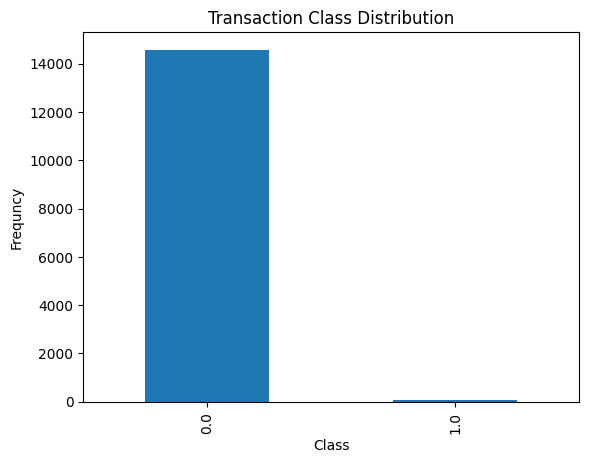

In [10]:
ax = creditcard_data.Class.value_counts().plot(kind='bar')

plt.title("Transaction Class Distribution")
plt.xlabel("Class")
plt.ylabel("Frequncy")

0-->Ligit(Normal)transaction

1-->Fraud transaction

As can seen, this is highly unbalanced the data. The noraml transaction is 284315 and only 492 is fraud transaction.

In [11]:
# seprating the data analysis
normal = creditcard_data[creditcard_data.Class == 0]
fraud = creditcard_data[creditcard_data.Class == 1]

In [12]:
print(normal.shape)
print(fraud.shape)

(14574, 31)
(61, 31)


In [13]:
nt = len(normal)/len(creditcard_data)*100
print(nt)

99.57638699098115


In [14]:
ft = len(fraud)/len(creditcard_data)*100
print(ft)

0.4167805411314567


Only 0.17% fraudulent transaction out all the transactions. The data is highly Unbalanced. Lets first apply our models without balancing it and if we don’t get a good accuracy then we can find a way to balance this dataset. But first, let’s implement the model without it and will balance the data only if needed.

In [15]:
# seprating the data amount wise analysis
normal.Amount.describe()

,Amount
count,14574.000000
mean,64.161752
std,177.112856
min,0.000000
25%,5.530000
50%,15.950000
75%,52.990000
max,7712.430000


In [16]:
fraud.Amount.describe()

,Amount
count,61.000000
mean,88.402295
std,297.522823
min,0.000000
25%,1.000000
50%,1.000000
75%,3.790000
max,1809.680000


As we can clearly notice from this, the average Money transaction for the fraudulent ones is more. This makes this problem crucial to deal with.

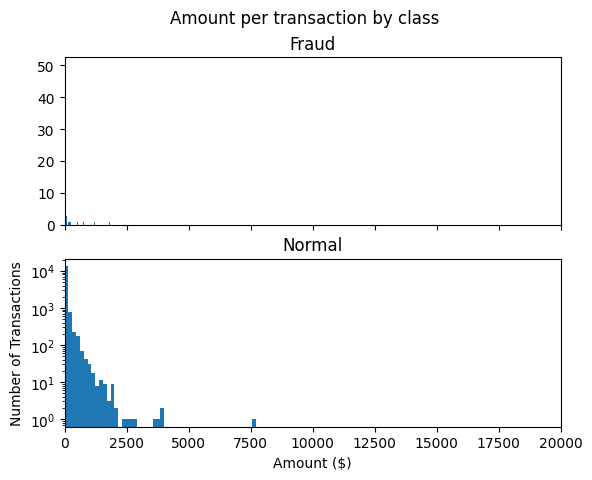

In [17]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Amount per transaction by class')
bins = 50
ax1.hist(fraud.Amount, bins = bins)
ax1.set_title('Fraud')
ax2.hist(normal.Amount, bins = bins)
ax2.set_title('Normal')
plt.xlabel('Amount ($)')
plt.ylabel('Number of Transactions')
plt.xlim((0, 20000))
plt.yscale('log')
plt.show();

<Axes: >

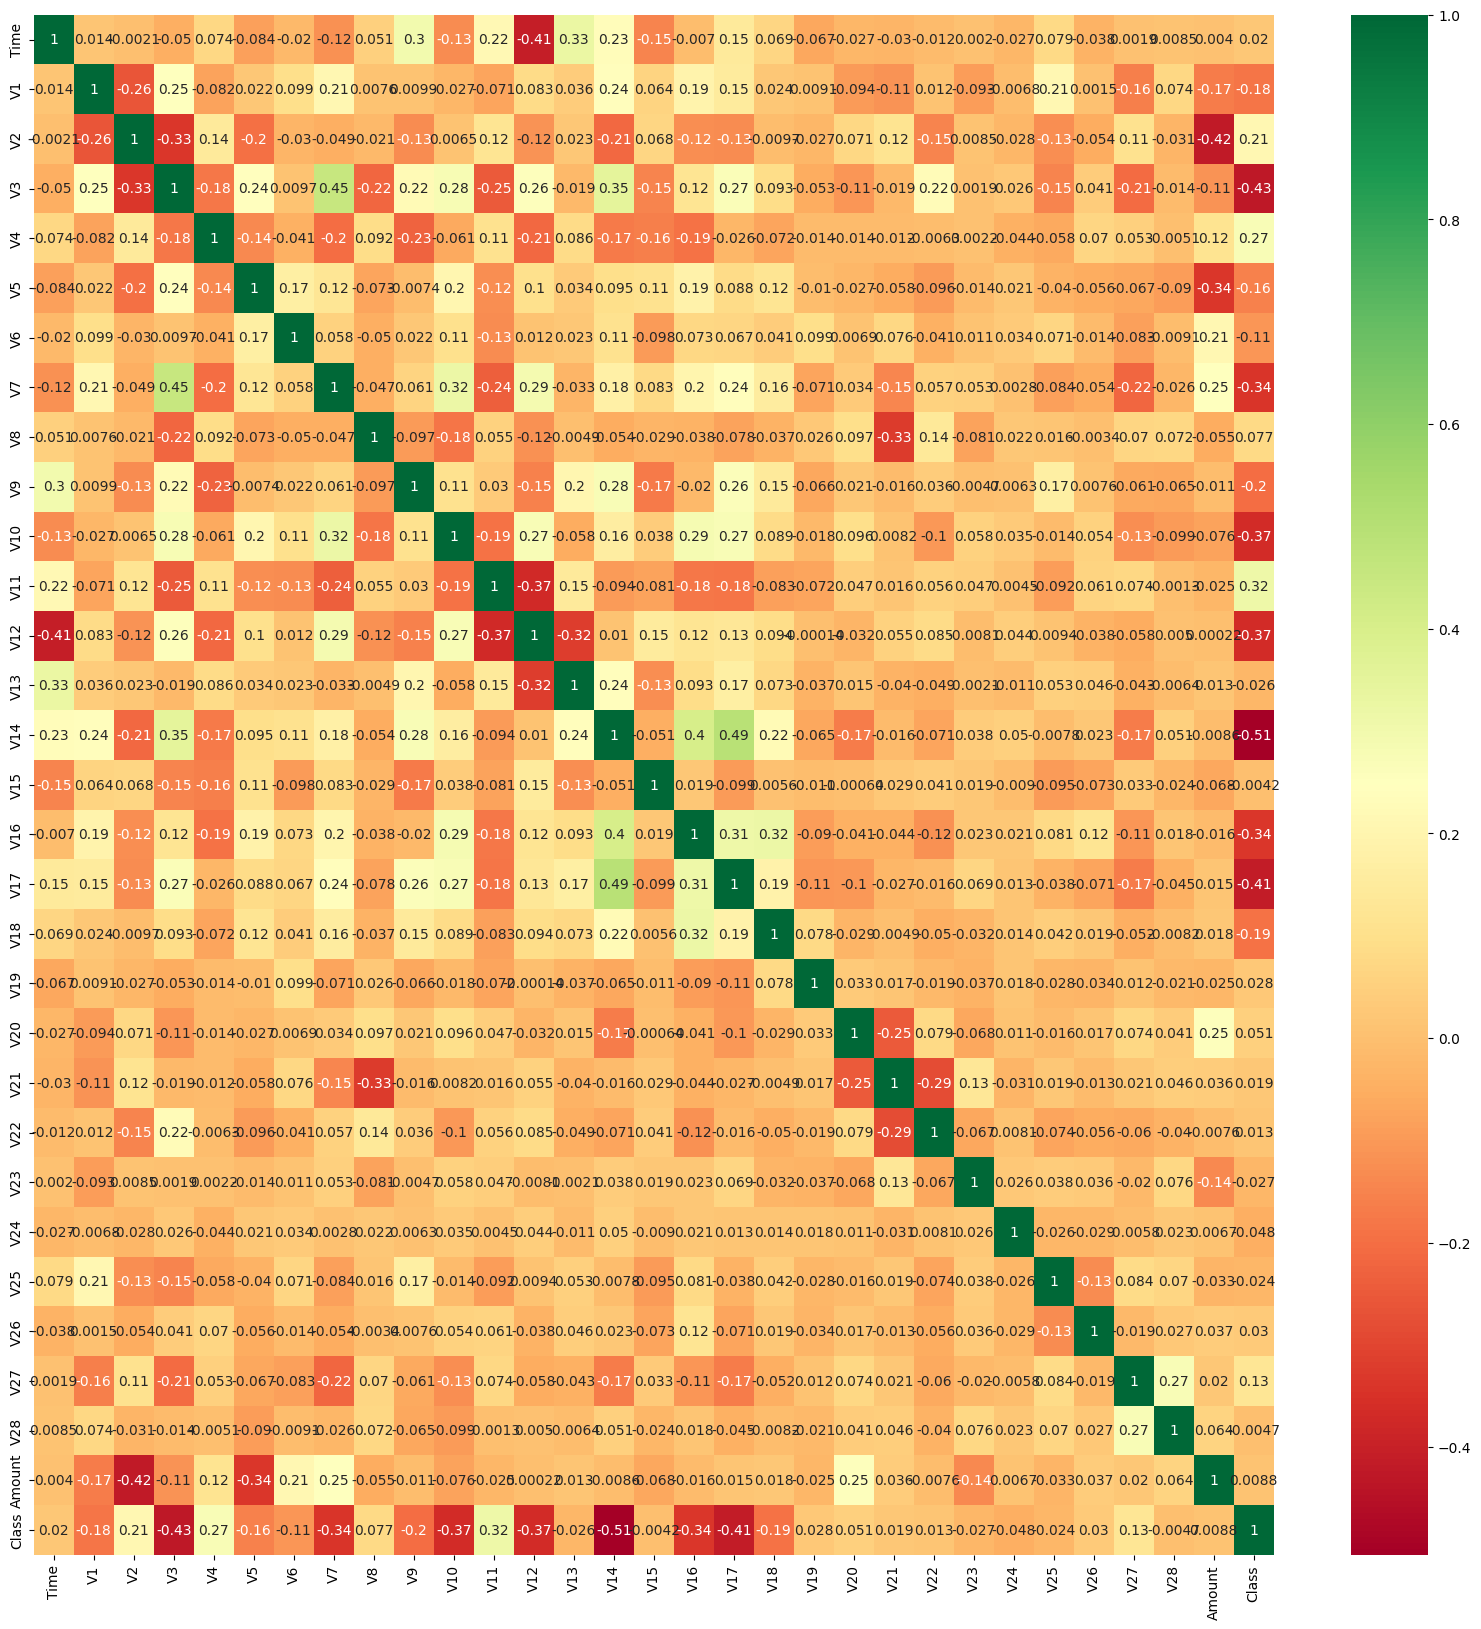

In [18]:
plt.figure(figsize=(20,20))
sns.heatmap(creditcard_data.corr(),cmap="RdYlGn", annot=True)

In the HeatMap we can clearly see that most of the features do not correlate to other features but there are some features that either has a positive or a negative correlation with each other. For example, V2 and V5 are highly negatively correlated with the feature called Amount. We also see some correlation with V20 and Amount. This gives us a deeper understanding of the Data available to us.

# Handale The Unbalanced Data - Under Sampling

The data is highly unbalanced. The noraml transaction is 284315 and only 492 is fraud transaction.

Using the under sampling method we balance the data.

In [19]:
ligit = normal.sample(n=492)

In [20]:
# using the under sampling method merage the ligit and fraud dataframe
new_df  = pd.concat([ligit,fraud], axis = 0)

In [21]:
new_df["Class"].value_counts()

,count
Class,
0.0,492
1.0,61


As can seen clearly now the data is balance.

# Splitting the data into Features & Targets

In [22]:
x = new_df.drop(columns= "Class", axis = 1)
y = new_df.Class

# Split the data into Training data & Testing Data

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state= 40)

In [24]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(442, 30) (111, 30) (442,) (111,)


In [25]:
creditcard_data.shape

(14636, 31)

# Hyper-Parameter Tuning

# Model Train

In [26]:
model_params = {
    'logistic regression' : {
        'model': LogisticRegression(),
        'parameter' : {
            'solver': ['liblinear']
        }
    },
    'svm' : {
        'model' : svm.SVC(),
        'parameter' : {
            'kernel' : ['rbf','linear'],
            'C' : [10,15,20]
        }
    },
    'decision tree' : {
        'model' : DecisionTreeClassifier(),
        'parameter' : {
            'criterion' : ['gini', 'entropy']
        }
    },
    'random forest' : {
        'model': RandomForestClassifier(),
        'parameter' : {
            'criterion': ['gini','entropy'],
            'n_estimators' : [50,100,150]
        }
    },
    'naive_bayes_gaussian' : {
        'model' : GaussianNB(),
        'parameter' : {}
    },
    'k nearest neighbors': {
        'model' : KNeighborsClassifier(),
        'parameter' : {
            'n_neighbors' : [5,10,15]
        }
    }
}

In [27]:
score = []

for model_name, mp in model_params.items():
    clf = GridSearchCV(mp['model'], mp['parameter'], cv=5)
    clf.fit(x_train,y_train)
    score.append({
        'model' : model_name,
        'best_score' : clf.best_score_,
        'best_params' : clf.best_params_
    })

cc_df = pd.DataFrame(score, columns = ['model', 'best_score', 'best_params'])
cc_df

,model,best_score,best_params
0,logistic regression,0.972906,{'solver': 'liblinear'}
1,svm,0.975153,"{'C': 10, 'kernel': 'linear'}"
2,decision tree,0.977375,{'criterion': 'entropy'}
3,random forest,0.986440,"{'criterion': 'gini', 'n_estimators': 150}"
4,naive_bayes_gaussian,0.963815,{}
5,k nearest neighbors,0.880133,{'n_neighbors': 10}
